# Data Preprocessing

### Load epoched data as a pandas dataframe

In [2]:
import pandas as pd

df = pd.read_pickle("../data/epoched_train.pkl")

print(df.shape)
print(df.columns)

(3680, 9)
Index(['patient_id', 'start_time', 'event_type', 'C3', 'Cz', 'C4', 'EOG:ch01',
       'EOG:ch02', 'EOG:ch03'],
      dtype='object')


### Extract General Information From the Dataframe

In [3]:
# 1. High-level summary (column types, non-null counts, memory usage)
df.info()

# 2. Preview the first few rows (metadata and signal lists)
print(df.head(2))

# 3. Check for missing values in any column
print(df.isnull().sum())

# 4. Count trials per patient to check for data imbalance
patient_counts = df['patient_id'].value_counts().sort_index()
print(patient_counts)

# 5. Descriptive statistics for metadata (like patient IDs)
print(df['patient_id'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  3680 non-null   object 
 1   start_time  3680 non-null   float64
 2   event_type  3680 non-null   object 
 3   C3          3680 non-null   object 
 4   Cz          3680 non-null   object 
 5   C4          3680 non-null   object 
 6   EOG:ch01    3680 non-null   object 
 7   EOG:ch02    3680 non-null   object 
 8   EOG:ch03    3680 non-null   object 
dtypes: float64(1), object(8)
memory usage: 258.9+ KB
  patient_id  start_time event_type  \
0     B0101T    223556.0          0   
1     B0101T    232996.0          1   

                                                  C3  \
0  [-3.6285954070344086, -2.337682154573892, -3.6...   
1  [2.9480430304417484, -0.05493247882810711, 0.3...   

                                                  Cz  \
0  [-2.920576791027695, -2.47501335164416, -2.

### Visual of EEG signals vs time

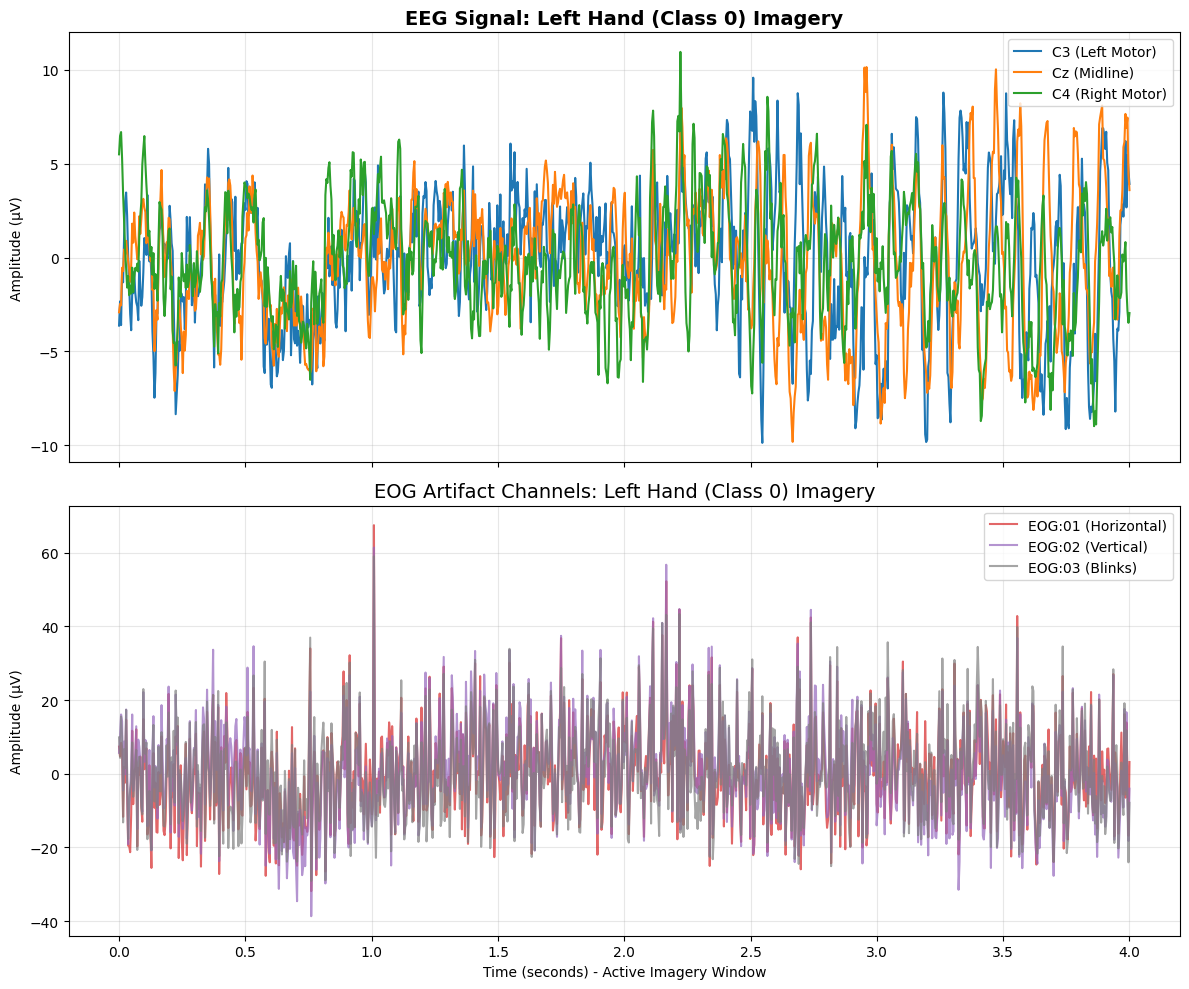

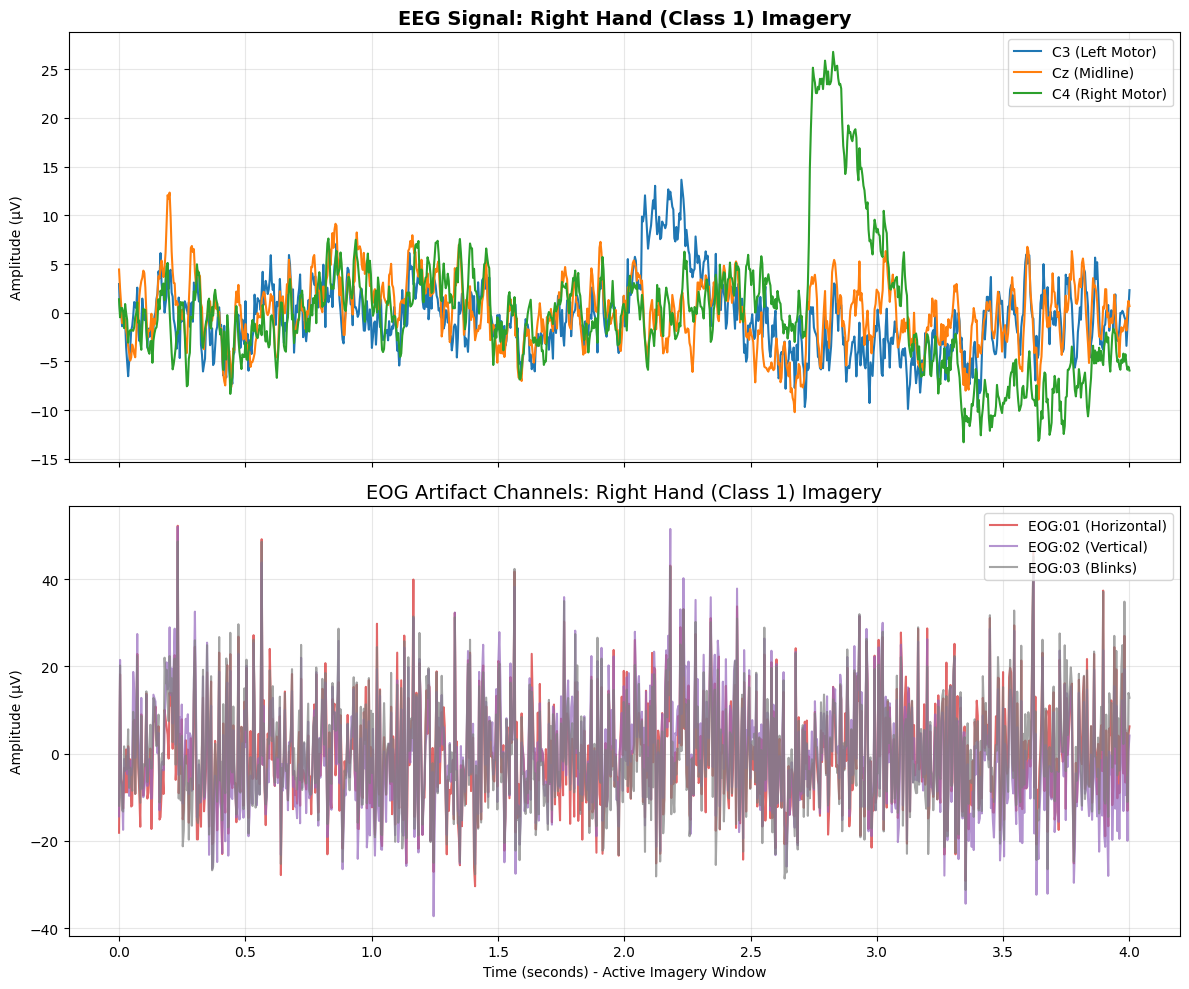

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Select one sample for each event type
# Converting to int in case they are stored as strings '0'/'1'
sample_left = df[df['event_type'].astype(int) == 0].iloc[0]
sample_right = df[df['event_type'].astype(int) == 1].iloc[0]

# 2. Define the Time Axis (1000 points over 4 seconds)
time = np.linspace(0, 4, 1000)

def plot_event(sample, event_label):
    # Create a figure with two subplots (EEG top, EOG bottom)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
    
    # Plot EEG Channels with distinct colors
    ax1.plot(time, sample['C3'], label='C3 (Left Motor)', color='#1f77b4', linewidth=1.5)
    ax1.plot(time, sample['Cz'], label='Cz (Midline)', color='#ff7f0e', linewidth=1.5)
    ax1.plot(time, sample['C4'], label='C4 (Right Motor)', color='#2ca02c', linewidth=1.5)
    ax1.set_title(f"EEG Signal: {event_label} Imagery", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Amplitude (µV)")
    ax1.legend(loc='upper right')
    ax1.grid(True, alpha=0.3)
    
    # Plot EOG Channels with distinct colors
    ax2.plot(time, sample['EOG:ch01'], label='EOG:01 (Horizontal)', color='#d62728', alpha=0.7)
    ax2.plot(time, sample['EOG:ch02'], label='EOG:02 (Vertical)', color='#9467bd', alpha=0.7)
    ax2.plot(time, sample['EOG:ch03'], label='EOG:03 (Blinks)', color='#7f7f7f', alpha=0.7)
    ax2.set_title(f"EOG Artifact Channels: {event_label} Imagery", fontsize=14)
    ax2.set_ylabel("Amplitude (µV)")
    ax2.set_xlabel("Time (seconds) - Active Imagery Window")
    ax2.legend(loc='upper right')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Generate the plots
plot_event(sample_left, "Left Hand (Class 0)")
plot_event(sample_right, "Right Hand (Class 1)")

### Split the data into Training and Testing Data
Data is comprised of EEG and EOG signals of 9 subjects across 27 sessions.
Here we split the data such that 7 subjects are used for training the model and 2 subjects are used for testing the model.

In [5]:
# Define the IDs for your test subjects
test_prefixes = ['B08', 'B09']

# Create the Test DataFrame (Subjects 8 and 9)
test_df = df[df['patient_id'].str.startswith(tuple(test_prefixes))].copy()

# Create the Train DataFrame (Subjects 1 through 7)
# The ~ symbol means "NOT", so this takes everything else
train_df = df[~df['patient_id'].str.startswith(tuple(test_prefixes))].copy()

# Verification
print(f"Training trials: {len(train_df)} (Subjects 1-7)")
print(f"Testing trials: {len(test_df)} (Subjects 8-9)")
print("\nSubjects in Test Set:", test_df['patient_id'].unique())

Training trials: 2840 (Subjects 1-7)
Testing trials: 840 (Subjects 8-9)

Subjects in Test Set: ['B0801T' 'B0802T' 'B0803T' 'B0901T' 'B0902T' 'B0903T']


## Feature Extraction
### Flattening the features into a model friendly representation

In [6]:
# Define the IDs for your test subjects
test_prefixes = ['B08', 'B09']

# Create the Test DataFrame (Subjects 8 and 9)
test_df = df[df['patient_id'].str.startswith(tuple(test_prefixes))].copy()

# Create the Train DataFrame (Subjects 1 through 7)
# The ~ symbol means "NOT", so this takes everything else
train_df = df[~df['patient_id'].str.startswith(tuple(test_prefixes))].copy()

# Verification
print(f"Training trials: {len(train_df)} (Subjects 1-7)")
print(f"Testing trials: {len(test_df)} (Subjects 8-9)")
print("\nSubjects in Test Set:", test_df['patient_id'].unique())

Training trials: 2840 (Subjects 1-7)
Testing trials: 840 (Subjects 8-9)

Subjects in Test Set: ['B0801T' 'B0802T' 'B0803T' 'B0901T' 'B0902T' 'B0903T']


In [7]:
def extract_features(target_df):
    # Convert the lists in columns into a 3D numpy array (trials, channels, timepoints)
    signal_cols = ["C3", "Cz", "C4", "EOG:ch01", "EOG:ch02", "EOG:ch03"]
    X_list = []
    for _, row in target_df.iterrows():
        trial = np.array([np.array(row[col]) for col in signal_cols])
        X_list.append(trial)
    
    X = np.array(X_list)
    y = target_df['event_type'].astype(int).values
    return X, y

# Get your final split arrays
X_train, y_train = extract_features(train_df)
X_test, y_test = extract_features(test_df)

print("Final X_train shape:", X_train.shape) # Should be (~2840, 6, 1000)
print("Final X_test shape:", X_test.shape)   # Should be (~840, 6, 1000)

Final X_train shape: (2840, 6, 1000)
Final X_test shape: (840, 6, 1000)


# Processing

### Logistic Regression with flattened variables

Training on 2840 trials (Subjects 1-7)
Testing on 840 trials (Subjects 8-9)

--- Evaluating Logistic Regression ---
Accuracy: 0.6714
              precision    recall  f1-score   support

        Left       0.69      0.62      0.65       420
       Right       0.66      0.72      0.69       420

    accuracy                           0.67       840
   macro avg       0.67      0.67      0.67       840
weighted avg       0.67      0.67      0.67       840


--- Evaluating RBF SVM ---
Accuracy: 0.6714
              precision    recall  f1-score   support

        Left       0.70      0.61      0.65       420
       Right       0.65      0.73      0.69       420

    accuracy                           0.67       840
   macro avg       0.67      0.67      0.67       840
weighted avg       0.67      0.67      0.67       840



<module 'matplotlib.pyplot' from '/Users/mataha/Downloads/GitHub/ML-Project/.venv/lib/python3.14/site-packages/matplotlib/pyplot.py'>

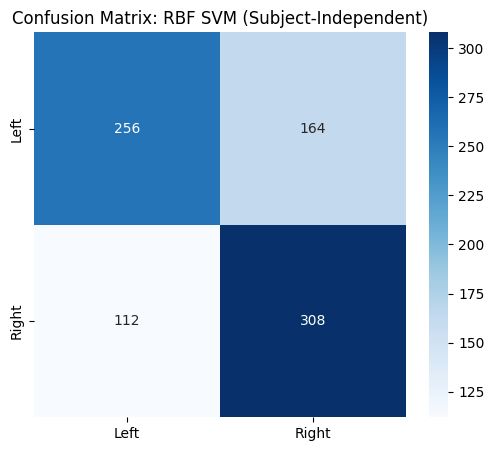

In [11]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. SPLIT DATAFRAMES BY SUBJECT
test_prefixes = ['B08', 'B09']
test_df = df[df['patient_id'].str.startswith(tuple(test_prefixes))].copy()
train_df = df[~df['patient_id'].str.startswith(tuple(test_prefixes))].copy()

# 2. FEATURE EXTRACTION FUNCTION
def prepare_arrays(target_df):
    signal_cols = ["C3", "Cz", "C4", "EOG:ch01", "EOG:ch02", "EOG:ch03"]
    
    # Convert lists to a 3D array: (trials, channels, timepoints)
    X_list = []
    for _, row in target_df.iterrows():
        trial = np.array([np.array(row[col]) for col in signal_cols])
        X_list.append(trial)
    
    X_3d = np.array(X_list)
    
    # FLATTEN: Combine channels and timepoints into one long vector
    # (trials, 6 * 1000) = (trials, 6000)
    X_flat = X_3d.reshape(X_3d.shape[0], -1)
    
    # Get Labels
    y = target_df['event_type'].astype(int).values
    
    return X_flat, y

# Execute extraction
X_train, y_train = prepare_arrays(train_df)
X_test, y_test = prepare_arrays(test_df)

# 3. SCALING (Crucial for SVM)
# Fit only on training data to avoid leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training on {len(train_df)} trials (Subjects 1-7)")
print(f"Testing on {len(test_df)} trials (Subjects 8-9)")

# 4. LOGISTIC REGRESSION
print("\n--- Evaluating Logistic Regression ---")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=['Left', 'Right']))

# 5. RBF SVM (Your best performing model previously)
print("\n--- Evaluating RBF SVM ---")
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_rbf.fit(X_train_scaled, y_train)
y_pred_svm = svm_rbf.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Left', 'Right']))

# 6. CONFUSION MATRIX (For the best model)
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Left', 'Right'], yticklabels=['Left', 'Right'])
plt.title("Confusion Matrix: RBF SVM (Subject-Independent)")
plt

CNN Training Shape: (2840, 1000, 6)
CNN Testing Shape: (840, 1000, 6)


/Users/mataha/Downloads/GitHub/ML-Project/.venv/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Neural Network ---
Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.6098 - loss: 0.9032 - val_accuracy: 0.6536 - val_loss: 0.6502
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.7183 - loss: 0.5216 - val_accuracy: 0.6655 - val_loss: 0.7761
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.7664 - loss: 0.4593 - val_accuracy: 0.6929 - val_loss: 0.7602
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.8001 - loss: 0.4224 - val_accuracy: 0.7071 - val_loss: 0.7252
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8181 - loss: 0.3838 - val_accuracy: 0.6929 - val_loss: 0.8613
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - accuracy: 0.8366 - loss: 0.3451 - val_accuracy: 0.6893 - val_loss: 1.0755
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.8680 - loss: 0.2858 - val_accuracy: 0.7238 - val_loss: 0.9586
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8699 - loss: 

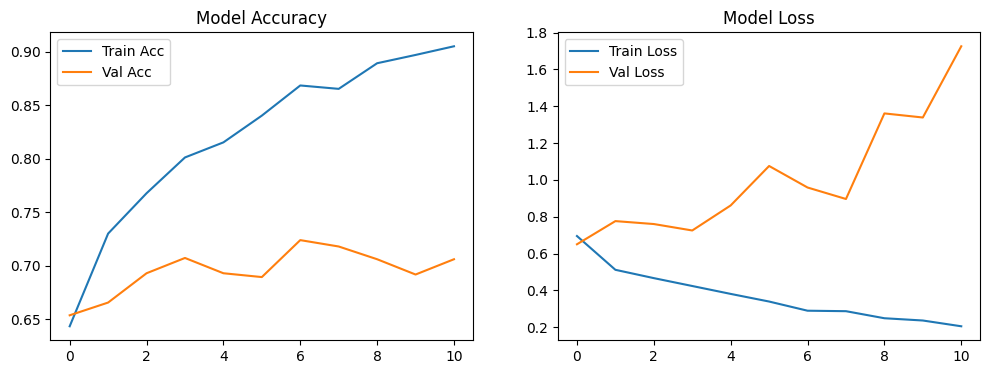

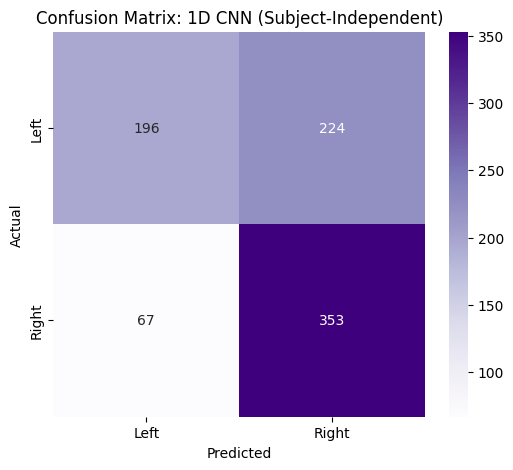

In [8]:
import numpy as np
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. PREPARE DATA FOR CNN (Do not flatten!)
def prepare_cnn_arrays(target_df):
    signal_cols = ["C3", "Cz", "C4", "EOG:ch01", "EOG:ch02", "EOG:ch03"]
    
    X_list = []
    for _, row in target_df.iterrows():
        # Shape: (channels, timepoints) -> (6, 1000)
        trial = np.array([np.array(row[col]) for col in signal_cols])
        X_list.append(trial)
    
    X_3d = np.array(X_list)
    
    # Keras Conv1D expects shape: (trials, timepoints, channels)
    # We transpose axes 1 and 2 to reshape from (trials, 6, 1000) to (trials, 1000, 6)
    X_cnn = np.transpose(X_3d, (0, 2, 1))
    
    y = target_df['event_type'].astype(int).values
    return X_cnn, y

X_train_cnn, y_train_cnn = prepare_cnn_arrays(train_df)
X_test_cnn, y_test_cnn = prepare_cnn_arrays(test_df)

print(f"CNN Training Shape: {X_train_cnn.shape}")
print(f"CNN Testing Shape: {X_test_cnn.shape}")

# 2. SCALING ALONG THE TIME AXIS
# We scale each channel independently to mean 0, variance 1
X_train_scaled = np.zeros_like(X_train_cnn)
X_test_scaled = np.zeros_like(X_test_cnn)

for i in range(X_train_cnn.shape[2]): # For each of the 6 channels
    mean_val = np.mean(X_train_cnn[:, :, i])
    std_val = np.std(X_train_cnn[:, :, i])
    
    X_train_scaled[:, :, i] = (X_train_cnn[:, :, i] - mean_val) / std_val
    X_test_scaled[:, :, i] = (X_test_cnn[:, :, i] - mean_val) / std_val

# 3. BUILD THE NEURAL NETWORK ARCHITECTURE
model = Sequential([
    # First Convolutional Block (Extracts high-frequency temporal features)
    Conv1D(filters=32, kernel_size=10, activation='relu', input_shape=(1000, 6)),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.3), # Heavy dropout to prevent overfitting on noisy EEG data
    
    # Second Convolutional Block (Extracts complex, longer patterns)
    Conv1D(filters=64, kernel_size=10, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=4),
    Dropout(0.3),
    
    # Flatten and Classify
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid') # Binary classification (Left=0, Right=1)
])

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# 4. TRAIN THE MODEL WITH EARLY STOPPING
# Early stopping halts training if the validation loss stops improving, preventing overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

print("\n--- Training Neural Network ---")
history = model.fit(X_train_scaled, y_train_cnn, 
                    epochs=50, 
                    batch_size=32, 
                    validation_data=(X_test_scaled, y_test_cnn),
                    callbacks=[early_stop],
                    verbose=1)

# 5. EVALUATE THE MODEL
print("\n--- Evaluating Neural Network ---")
# Predict probabilities, then convert to 0 or 1
y_pred_probs = model.predict(X_test_scaled)
y_pred_nn = (y_pred_probs > 0.5).astype(int).flatten()

print(f"Accuracy: {accuracy_score(y_test_cnn, y_pred_nn):.4f}")
print(classification_report(y_test_cnn, y_pred_nn, target_names=['Left', 'Right']))

# 6. PLOT TRAINING HISTORY
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Model Accuracy')
ax1.legend()

ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss')
ax2.legend()
plt.show()

# 7. CONFUSION MATRIX
cm = confusion_matrix(y_test_cnn, y_pred_nn)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Left', 'Right'], yticklabels=['Left', 'Right'])
plt.title("Confusion Matrix: 1D CNN (Subject-Independent)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()